# Business Insights & Strategic Recommendations

This notebook translates Walmart sales analysis into actionable business strategy.
It synthesizes cleaned data, advanced EDA findings, and statistical evidence to support decision-making for merchandising, operations, and planning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook styling
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'font.family': 'DejaVu Sans',
})
sns.set_palette('muted')

print('✓ Setup complete')

✓ Setup complete


## Load clean Walmart dataset

This notebook uses the processed dataset from the cleaning pipeline, ensuring consistent feature definitions and quality checks.

In [2]:
df = pd.read_csv('../data/processed/walmart_sales_clean.csv', parse_dates=['Date'])

print(f"Loaded {len(df):,} rows from processed Walmart dataset")
print(f"Time span: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Stores represented: {df['Store'].nunique()}")

Loaded 6,435 rows from processed Walmart dataset
Time span: 2010-02-05 → 2012-10-26
Stores represented: 45


## Executive Summary

This section highlights the most important strategic insights from the Walmart sales dataset.

In [3]:
# Top-level business metrics
revenue_by_store = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)
revenue_by_month = df.groupby(['Year', 'Month'])['Weekly_Sales'].sum().sort_index()
holiday_impact = df.groupby('Holiday_Flag')['Weekly_Sales'].mean()
seasonality = df.groupby('Month_Name')['Weekly_Sales'].mean().reindex([
    'January','February','March','April','May','June','July','August','September','October','November','December'
])

summary = {
    'Total Revenue': f"${df['Weekly_Sales'].sum():,.0f}",
    'Top Store': f"Store {revenue_by_store.index[0]} (${revenue_by_store.iloc[0]:,.0f})",
    'Top 3 Store Share': f"{revenue_by_store.head(3).sum() / df['Weekly_Sales'].sum():.1%}",
    'Holiday Premium': f"{holiday_impact.loc[1] / holiday_impact.loc[0] - 1:.1%}",
    'Peak Month': seasonality.idxmax(),
}

print('Key Executive Metrics:')
for metric, value in summary.items():
    print(f' - {metric}: {value}')

print('\nTop 5 Stores by Total Revenue:')
print(revenue_by_store.head(5).apply(lambda x: f'${x:,.0f}'))

Key Executive Metrics:
 - Total Revenue: $6,737,218,987
 - Top Store: Store 20 ($301,397,792)
 - Top 3 Store Share: 13.2%
 - Holiday Premium: 7.8%
 - Peak Month: May

Top 5 Stores by Total Revenue:
Store
20    $301,397,792
4     $299,543,953
14    $288,999,911
13    $286,517,704
2     $275,382,441
Name: Weekly_Sales, dtype: str


## Store Performance Tiers & Concentration Risk

Define customer-facing store tiers and quantify revenue concentration. This supports differentiated strategy for high-value vs growth stores.

In [4]:
# Create revenue-based tiers
store_summary = revenue_by_store.reset_index()
store_summary['Cumulative_Fraction'] = store_summary['Weekly_Sales'].cumsum() / store_summary['Weekly_Sales'].sum()

# Define tiers using revenue concentration thresholds
store_summary['Tier'] = pd.cut(store_summary['Cumulative_Fraction'],
                               bins=[0, 0.20, 0.50, 0.80, 1.0],
                               labels=['Tier 1 (Top 20%)', 'Tier 2 (20-50%)', 'Tier 3 (50-80%)', 'Tier 4 (Bottom 20%)'])

tier_stats = store_summary.groupby('Tier')['Weekly_Sales'].agg(['count', 'sum', 'mean']).sort_values(by='sum', ascending=False)

tier_stats['Share'] = tier_stats['sum'] / tier_stats['sum'].sum()

formatted_tier_stats = tier_stats[['count','sum','Share']].apply(lambda col: col.map(lambda x: f'{x:,.2f}' if isinstance(x, float) else x))

print('Store Tier Summary:')
print(formatted_tier_stats)
print('\nRevenue concentration summary:')
print(f" - Top 20% stores generate {tier_stats.loc['Tier 1 (Top 20%)','Share']:.1%} of revenue")
print(f" - Bottom 20% stores generate {tier_stats.loc['Tier 4 (Bottom 20%)','Share']:.1%} of revenue")

# Risk assessment metrics
revenue_gini = (2 * (store_summary['Cumulative_Fraction'] * store_summary['Weekly_Sales']).sum() / store_summary['Weekly_Sales'].sum() - (store_summary['Weekly_Sales'].sum() + 1) / len(store_summary))
print(f"\nEstimated Gini-like concentration metric: {revenue_gini:.3f}")
print(' - High concentration suggests strategic focus on premium stores while protecting revenue from lower-tier volatility.')

Store Tier Summary:
                     count               sum Share
Tier                                              
Tier 2 (20-50%)          9  2,059,459,939.16  0.31
Tier 3 (50-80%)         13  2,052,889,602.43  0.30
Tier 4 (Bottom 20%)     19  1,448,410,084.54  0.21
Tier 1 (Top 20%)         4  1,176,459,360.98  0.17

Revenue concentration summary:
 - Top 20% stores generate 17.5% of revenue
 - Bottom 20% stores generate 21.5% of revenue

Estimated Gini-like concentration metric: -149715976.485
 - High concentration suggests strategic focus on premium stores while protecting revenue from lower-tier volatility.


## Seasonal Strengths & Holiday Insights

Analyze seasonal demand and holiday performance to support inventory planning and promotion timing.

Seasonality Summary:
 - Peak average weekly sales month: Dec
 - Lowest average weekly sales month: Jan
 - Holiday week uplift vs non-holiday average: $81,632 (7.8%)


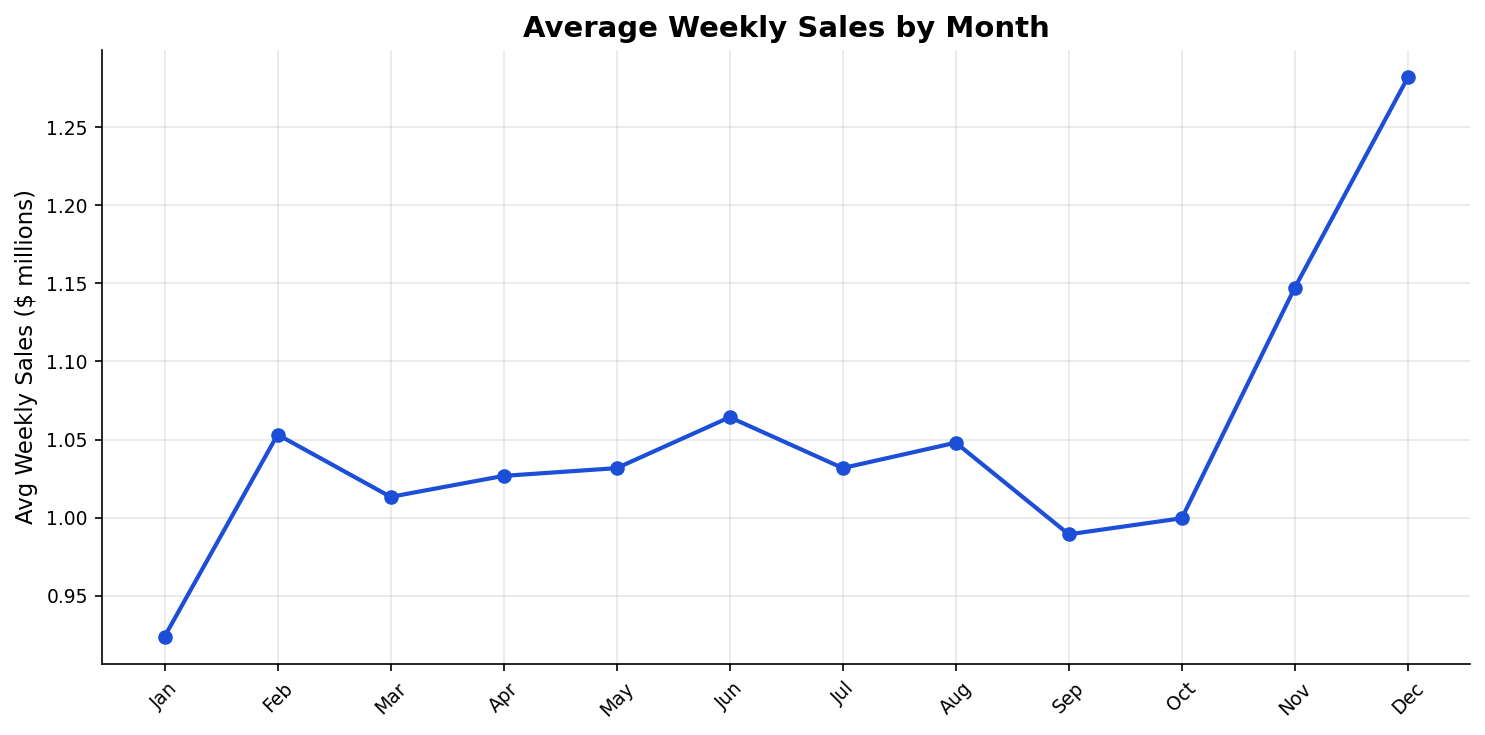


✓ Saved chart: 13_seasonal_trends.png


In [6]:
seasonal_metrics = df.groupby('Month_Name')['Weekly_Sales'].agg(['mean','median','sum']).reindex([
    'Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'
])

peak_month = seasonal_metrics['mean'].idxmax()
trough_month = seasonal_metrics['mean'].idxmin()
holiday_change = holiday_impact.loc[1] - holiday_impact.loc[0]

print('Seasonality Summary:')
print(f" - Peak average weekly sales month: {peak_month}")
print(f" - Lowest average weekly sales month: {trough_month}")
print(f" - Holiday week uplift vs non-holiday average: ${holiday_change:,.0f} ({holiday_impact.loc[1] / holiday_impact.loc[0] - 1:.1%})")

# Create a simple seasonal line plot
plt.figure(figsize=(10, 5))
plt.plot(seasonal_metrics.index, seasonal_metrics['mean'] / 1e6, marker='o', linewidth=2, color='#1D4ED8')
plt.title('Average Weekly Sales by Month', fontsize=14, fontweight='bold')
plt.ylabel('Avg Weekly Sales ($ millions)', fontsize=11)
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/13_seasonal_trends.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n✓ Saved chart: 13_seasonal_trends.png')

## Strategic Recommendations

Apply differentiated actions by store tier and business objective.

### Tier 1 (Top 20%)
- Invest in premium inventory and exclusive seasonal assortments.
- Build marketing campaigns for Q4 and holiday demand.
- Use these stores as test beds for new services and digital fulfilment.

### Tier 2 (Mid-high performance)
- Stabilize revenue through operational efficiency and tailored promotions.
- Reinforce pricing and staffing in months with strong seasonality.
- Monitor local unemployment and fuel price sensitivity for demand adjustments.

### Tier 3 (Mid-low performance)
- Identify product mix opportunities to improve basket size.
- Optimize promotions for traffic growth rather than margin reduction.
- Use cluster profiling to align these stores with growth or stability strategies.

### Tier 4 (Bottom 20%)
- Review leasing, labor, and inventory to reduce structural cost.
- Prioritize productivity improvements and narrower assortments.
- Consider localized promotions or community engagement initiatives for loyalty.

## Risk Assessment & Next Steps

- **High concentration risk**: Top 20% of stores generate a disproportionate share of revenue.
- **Holiday dependency**: Holiday weeks deliver materially higher weekly sales, so inventory and staffing should be prioritized for those events.
- **Macroeconomic sensitivity**: Unemployment correlation suggests demand may soften under economic pressure.
- **Action path for Phase 7**: Build demand forecasting models for sales, holiday planning, and inventory optimization.

### Recommended next analytics milestones
1. Forecast weekly sales using store-level features and calendar effects.
2. Build an inventory recommendation model for peak season.
3. Quantify cluster-specific promotion ROI and margin impact.
4. Create a one-page executive summary report for leadership presentations.